# AEP Hourly Energy Consumption Prediction

## Import Necessary Libraries

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit

# For time series features
import warnings
warnings.filterwarnings('ignore')

plt.style.use('bmh')
print("Libraries imported successfully!")

Libraries imported successfully!


## Load the Dataset

In [2]:
# Load the AEP hourly energy consumption data
df = pd.read_csv('AEP_hourly.csv')

# Convert Datetime column to datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

print(f"Dataset shape: {df.shape}")
print(f"Dataset info:")
print(df.info())
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names: {df.columns.tolist()}")

Dataset shape: (121273, 2)
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[ns]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 MB
None

First 5 rows:
             Datetime   AEP_MW
0 2004-12-31 01:00:00  13478.0
1 2004-12-31 02:00:00  12865.0
2 2004-12-31 03:00:00  12577.0
3 2004-12-31 04:00:00  12517.0
4 2004-12-31 05:00:00  12670.0

Column names: ['Datetime', 'AEP_MW']


## Exploratory Data Analysis

In [3]:
# Basic statistical information
print("\nBasic statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Basic statistics:
                            Datetime         AEP_MW
count                         121273  121273.000000
mean   2011-09-02 03:17:01.553025024   15499.513717
min              2004-10-01 01:00:00    9581.000000
25%              2008-03-17 15:00:00   13630.000000
50%              2011-09-02 04:00:00   15310.000000
75%              2015-02-16 17:00:00   17200.000000
max              2018-08-03 00:00:00   25695.000000
std                              NaN    2591.399065

Missing values:
Datetime    0
AEP_MW      0
dtype: int64

Duplicate rows: 0


In [4]:
# Extract time-based features
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour
df['Weekday'] = df['Datetime'].dt.weekday
df['WeekOfYear'] = df['Datetime'].dt.isocalendar().week.astype(int)

# Create time-based features for modeling
df['DayOfYear'] = df['Datetime'].dt.dayofyear
df['IsWeekend'] = (df['Weekday'] >= 5).astype(int)

# Display the updated dataset
print(df.head())
print(f"\nDataset shape after feature extraction: {df.shape}")

             Datetime   AEP_MW  Year  Month  Day  Hour  Weekday  WeekOfYear  \
0 2004-12-31 01:00:00  13478.0  2004     12   31     1        4          53   
1 2004-12-31 02:00:00  12865.0  2004     12   31     2        4          53   
2 2004-12-31 03:00:00  12577.0  2004     12   31     3        4          53   
3 2004-12-31 04:00:00  12517.0  2004     12   31     4        4          53   
4 2004-12-31 05:00:00  12670.0  2004     12   31     5        4          53   

   DayOfYear  IsWeekend  
0        366          0  
1        366          0  
2        366          0  
3        366          0  
4        366          0  

Dataset shape after feature extraction: (121273, 10)


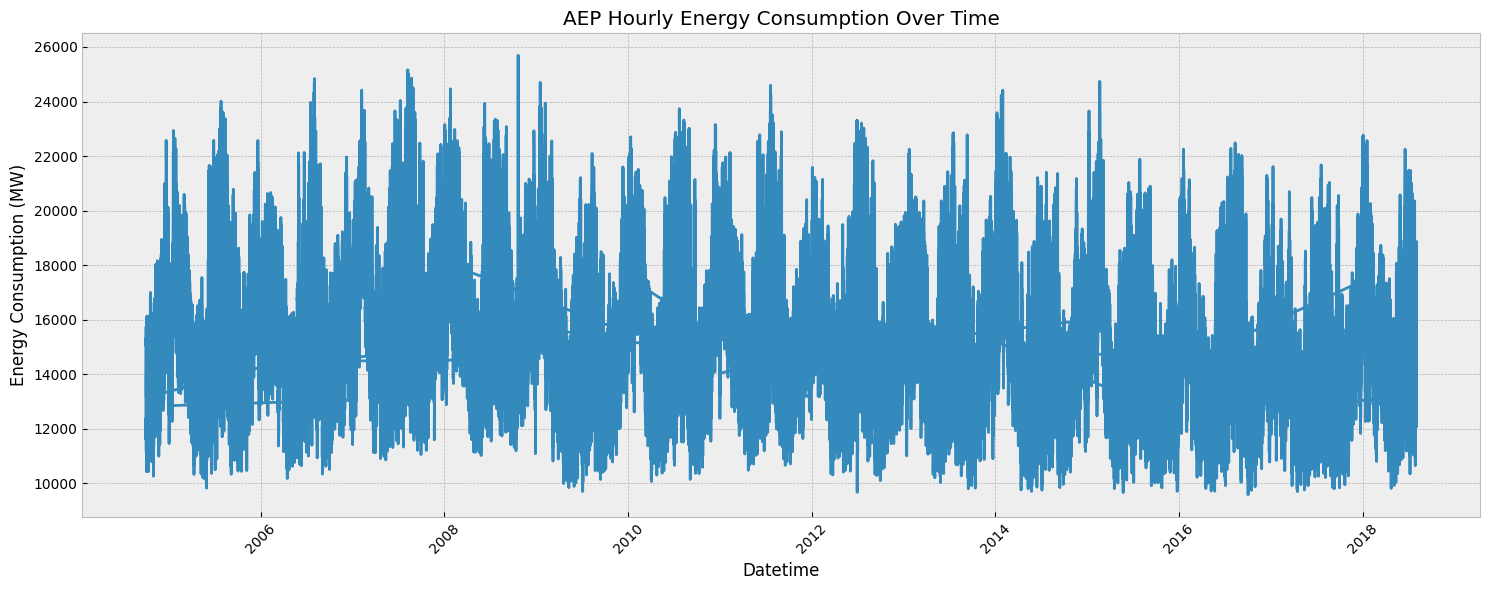

In [5]:
# Visualize the time series data
plt.figure(figsize=(15, 6))
plt.plot(df['Datetime'], df['AEP_MW'])
plt.title('AEP Hourly Energy Consumption Over Time')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

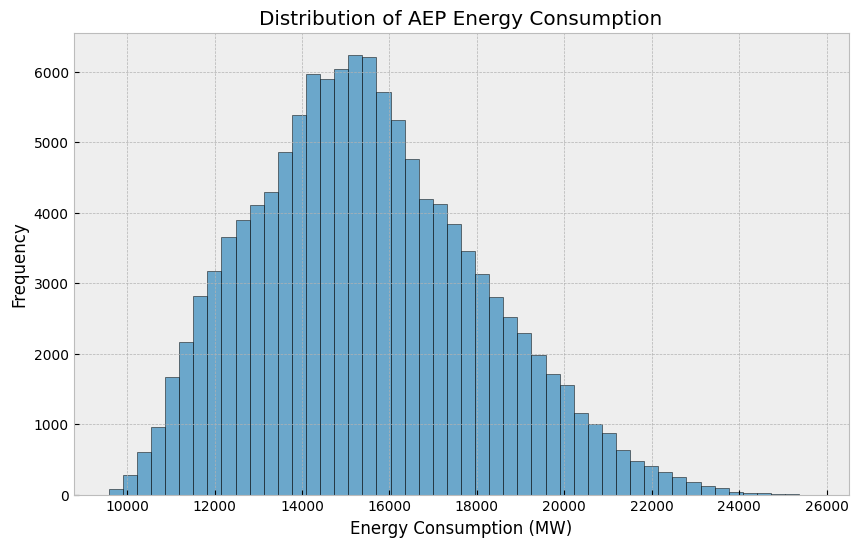

In [6]:
# Distribution of energy consumption
plt.figure(figsize=(10, 6))
plt.hist(df['AEP_MW'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of AEP Energy Consumption')
plt.xlabel('Energy Consumption (MW)')
plt.ylabel('Frequency')
plt.show()

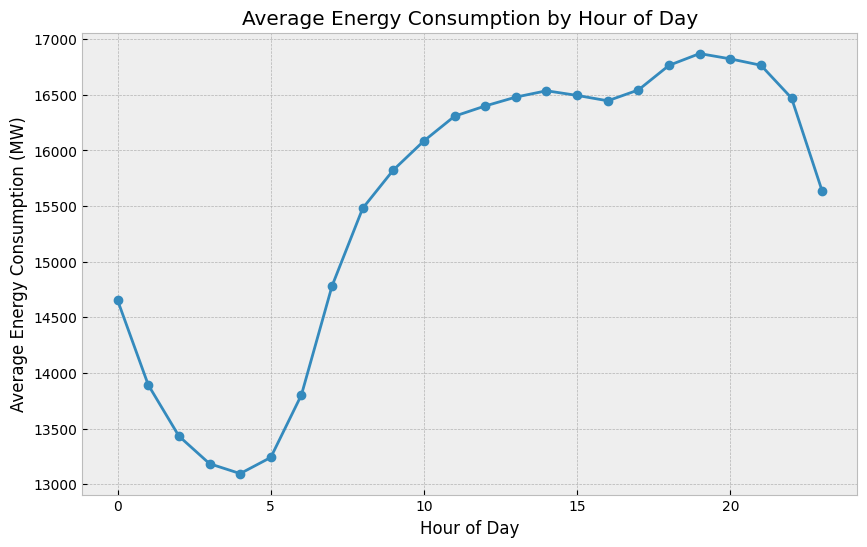

In [7]:
# Average energy consumption by hour
hourly_avg = df.groupby('Hour')['AEP_MW'].mean()
plt.figure(figsize=(10, 6))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.grid(True)
plt.show()

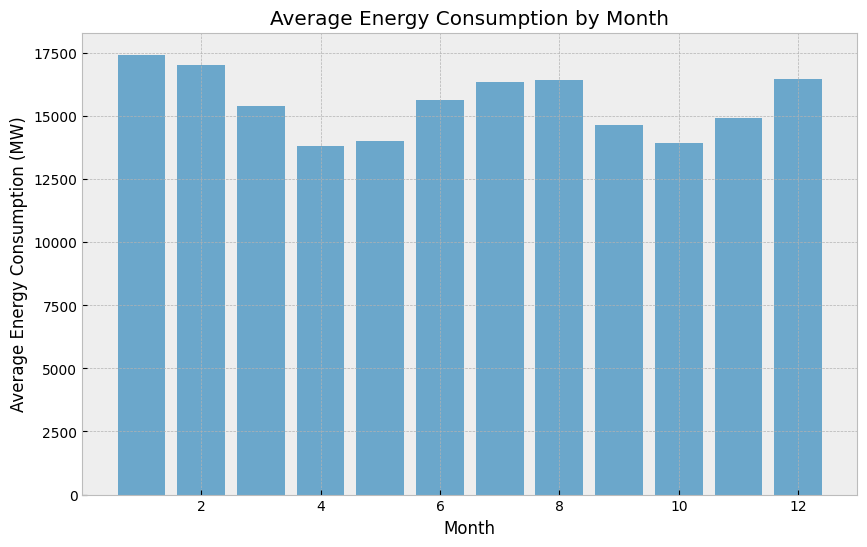

In [8]:
# Average energy consumption by month
monthly_avg = df.groupby('Month')['AEP_MW'].mean()
plt.figure(figsize=(10, 6))
plt.bar(monthly_avg.index, monthly_avg.values, alpha=0.7)
plt.title('Average Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (MW)')
plt.show()

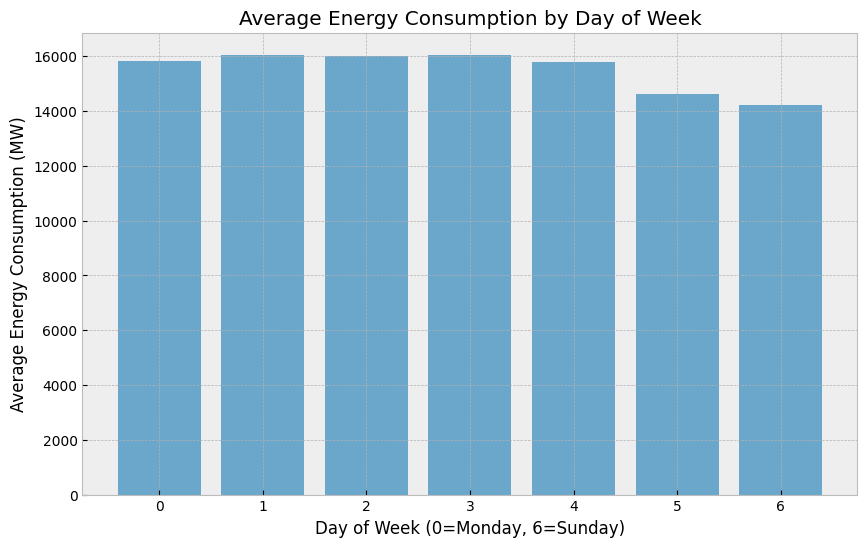

In [9]:
# Average energy consumption by weekday
weekday_avg = df.groupby('Weekday')['AEP_MW'].mean()
plt.figure(figsize=(10, 6))
plt.bar(weekday_avg.index, weekday_avg.values, alpha=0.7)
plt.title('Average Energy Consumption by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Energy Consumption (MW)')
plt.show()

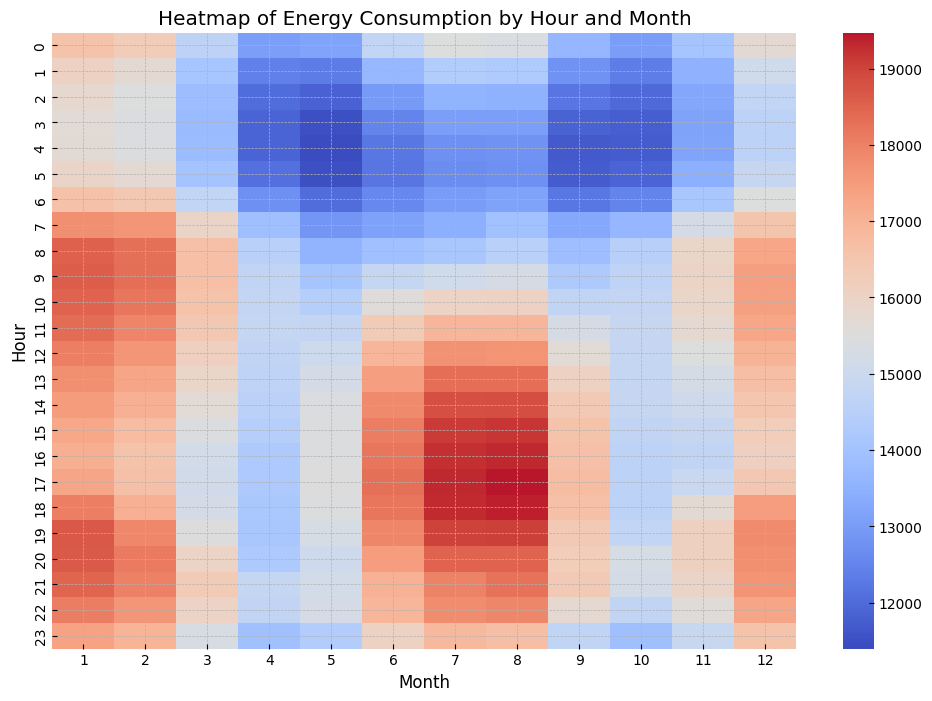

EDA completed!


In [12]:
# Heatmap showing energy consumption by hour and month
plt.figure(figsize=(12, 8))
energy_by_hour_month = df.groupby(['Hour', 'Month'])['AEP_MW'].mean().unstack()
sns.heatmap(energy_by_hour_month, cmap='coolwarm', center=energy_by_hour_month.mean().mean())
plt.title('Heatmap of Energy Consumption by Hour and Month')    
plt.show()

print("EDA completed!")

## Data Preprocessing for Machine Learning

In [21]:
# Create lagged features for time series prediction
df['AEP_MW_lag1'] = df['AEP_MW'].shift(1)  # Previous hour
df['AEP_MW_lag24'] = df['AEP_MW'].shift(24)  # Previous day
df['AEP_MW_lag168'] = df['AEP_MW'].shift(168)  # Previous week
    
    # Calculate rolling averages for different time windows
df['AEP_MW_rolling_mean_24'] = df['AEP_MW'].rolling(window=24).mean()  # 24-hour rolling mean
df['AEP_MW_rolling_mean_168'] = df['AEP_MW'].rolling(window=168).mean()  # 168-hour (1 week) rolling mean
    
    # Drop rows with NaN values introduced by lagging and rolling operations
df_clean = df.dropna()
    
print(f"Dataset shape after preprocessing: {df_clean.shape}")
print(f"Columns in final dataset: {df_clean.columns.tolist()}")

Dataset shape after preprocessing: (121105, 15)
Columns in final dataset: ['Datetime', 'AEP_MW', 'Year', 'Month', 'Day', 'Hour', 'Weekday', 'WeekOfYear', 'DayOfYear', 'IsWeekend', 'AEP_MW_lag1', 'AEP_MW_lag24', 'AEP_MW_lag168', 'AEP_MW_rolling_mean_24', 'AEP_MW_rolling_mean_168']


In [22]:
# Select feature columns for the model
feature_cols = ['Year', 'Month', 'Day', 'Hour', 'Weekday', 'DayOfYear', 'IsWeekend', 
           'AEP_MW_lag1', 'AEP_MW_lag24', 'AEP_MW_lag168', 
           'AEP_MW_rolling_mean_24', 'AEP_MW_rolling_mean_168']
    
    # Define target variable
target_col = 'AEP_MW'
    
X = df_clean[feature_cols]
y = df_clean[target_col]
    
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: {feature_cols}")

Feature matrix shape: (121105, 12)
Target vector shape: (121105,)
Features used: ['Year', 'Month', 'Day', 'Hour', 'Weekday', 'DayOfYear', 'IsWeekend', 'AEP_MW_lag1', 'AEP_MW_lag24', 'AEP_MW_lag168', 'AEP_MW_rolling_mean_24', 'AEP_MW_rolling_mean_168']


In [23]:
# Split the data into training and testing sets (time-aware split)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
    
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")
    
    # Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
   
print("Data preprocessing completed!")

Training set shape: (96884, 12), (96884,)
Testing set shape: (24221, 12), (24221,)
Data preprocessing completed!


## Model Building and Training

In [20]:
# Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
    
    # Make predictions on test set
y_pred_rf = rf_model.predict(X_test_scaled)
    
print("Random Forest model trained and predictions made!")

Random Forest model trained and predictions made!


In [24]:
# Initialize and train Linear Regression model
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
    
    # Make predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)
   
print("Linear Regression model trained and predictions made!")

Linear Regression model trained and predictions made!


## Model Evaluation and Visualization

In [25]:
# Calculate evaluation metrics for Random Forest
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)
    
print("Random Forest Model Performance:")
print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"Mean Absolute Error: {rf_mae:.2f}")
print(f"R2 Score: {rf_r2:.4f}")
    
    # Calculate evaluation metrics for Linear Regression
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
    
print(f"\nLinear Regression Model Performance:")
print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"Mean Absolute Error: {lr_mae:.2f}")
print(f"R2 Score: {lr_r2:.4f}")

Random Forest Model Performance:
Mean Squared Error: 78283.29
Mean Absolute Error: 170.88
R2 Score: 0.9881

Linear Regression Model Performance:
Mean Squared Error: 295423.23
Mean Absolute Error: 401.98
R2 Score: 0.9551


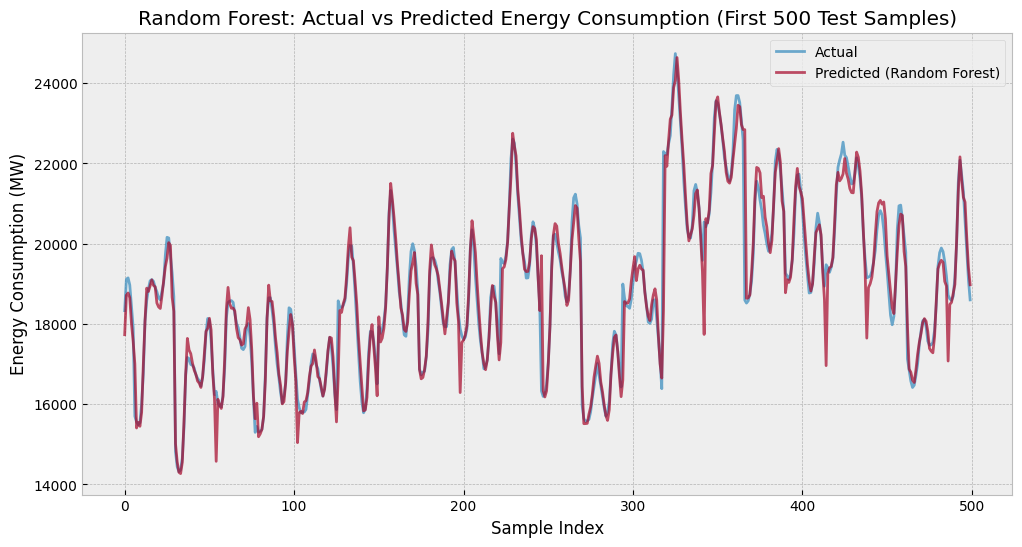

In [26]:
# Visualize actual vs predicted values for Random Forest
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:500], label='Actual', alpha=0.7)
plt.plot(y_pred_rf[:500], label='Predicted (Random Forest)', alpha=0.7)
plt.title('Random Forest: Actual vs Predicted Energy Consumption (First 500 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.show()

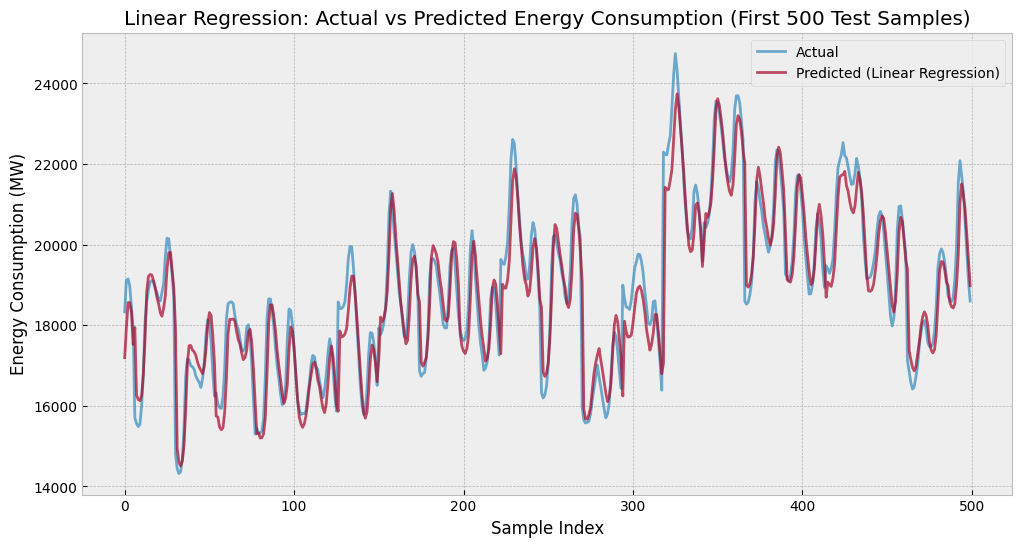

In [27]:
# Visualize actual vs predicted values for Linear Regression
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:500], label='Actual', alpha=0.7)
plt.plot(y_pred_lr[:500], label='Predicted (Linear Regression)', alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted Energy Consumption (First 500 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.show()

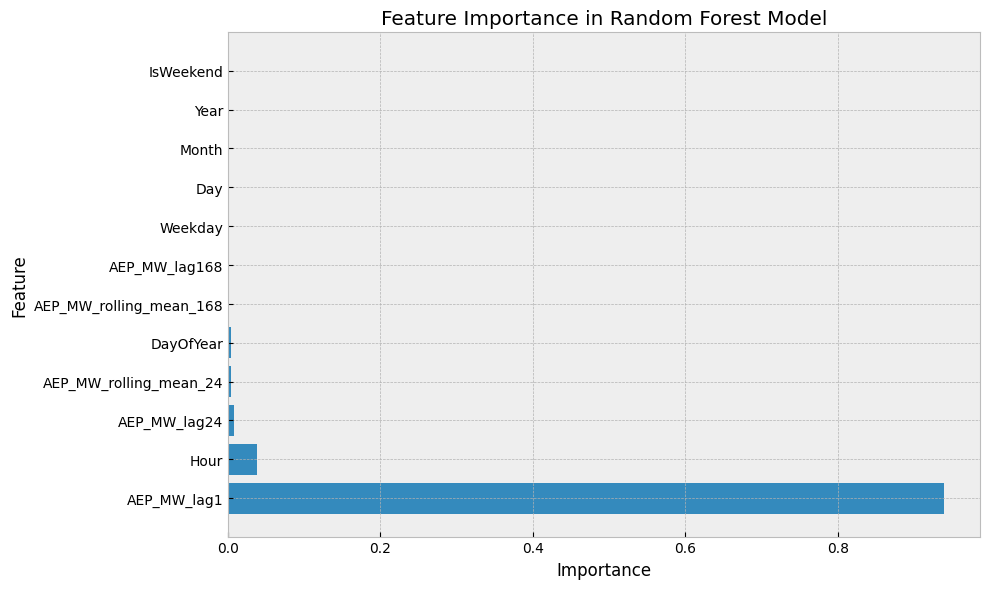

                    feature  importance
7               AEP_MW_lag1    0.939572
3                      Hour    0.038064
8              AEP_MW_lag24    0.007806
10   AEP_MW_rolling_mean_24    0.003820
5                 DayOfYear    0.003383
11  AEP_MW_rolling_mean_168    0.001566
9             AEP_MW_lag168    0.001497
4                   Weekday    0.001368
2                       Day    0.000809
1                     Month    0.000770
0                      Year    0.000742
6                 IsWeekend    0.000601


In [28]:
# Feature importance for Random Forest
feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
    
print(feature_importance)

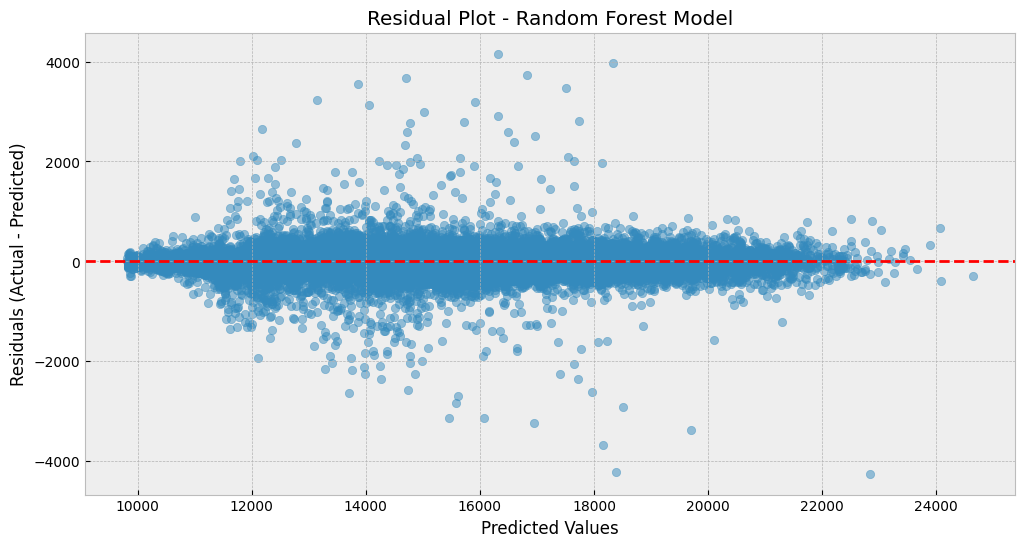

In [29]:
# Residual plot for Random Forest
residuals = y_test - y_pred_rf
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot - Random Forest Model')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

## Summary and Conclusion

In [31]:
best_model = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
best_r2 = max(rf_r2, lr_r2)
    
print("Model Comparison Summary:")
print(f"Random Forest R2 Score: {rf_r2:.4f}")
print(f"Linear Regression R2 Score: {lr_r2:.4f}")
print(f"Best Model: {best_model}")
print(f"Best R2 Score: {best_r2:.4f}")
    
print(f"\nThis model can help predict AEP hourly energy consumption based on time and lagged consumption values.")
print(f"The R2 score indicates how much of the variance in energy consumption is explained by the model.")

Model Comparison Summary:
Random Forest R2 Score: 0.9881
Linear Regression R2 Score: 0.9551
Best Model: Random Forest
Best R2 Score: 0.9881

This model can help predict AEP hourly energy consumption based on time and lagged consumption values.
The R2 score indicates how much of the variance in energy consumption is explained by the model.


## Save the Best Model and Results

In [32]:
# Save the trained Random Forest model
import joblib
    
    # Save the best performing model (Random Forest in this case)
joblib.dump(rf_model, 'aep_energy_consumption_rf_model.pkl')
print("Random Forest model saved as 'aep_energy_consumption_rf_model.pkl'")
    
    # Save the scaler as well since we normalized the features
joblib.dump(scaler, 'aep_energy_scaler.pkl')
print("Feature scaler saved as 'aep_energy_scaler.pkl'")
    
    # Save the processed dataset as backup
df_clean.to_csv('processed_AEP_hourly.csv', index=False)
print("Processed dataset saved as 'processed_AEP_hourly.csv'")
    
print("\nModel training and saving completed!")
    
    # Final summary
print(f"\nFinal Summary:")
print(f"- Original dataset shape: {df.shape}")
print(f"- Processed dataset shape: {df_clean.shape}")
print(f"- Features used: {len(feature_cols)}")
print(f"- Random Forest R2 Score: {rf_r2:.4f}")
print(f"- Linear Regression R2 Score: {lr_r2:.4f}")
  # Note: best_model should be defined earlier
best_model_name = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f"- Best performing model: {best_model_name}")

Random Forest model saved as 'aep_energy_consumption_rf_model.pkl'
Feature scaler saved as 'aep_energy_scaler.pkl'
Processed dataset saved as 'processed_AEP_hourly.csv'

Model training and saving completed!

Final Summary:
- Original dataset shape: (121273, 15)
- Processed dataset shape: (121105, 15)
- Features used: 12
- Random Forest R2 Score: 0.9881
- Linear Regression R2 Score: 0.9551
- Best performing model: Random Forest
